## Title :-Job Market Analysis

## 1.Import Libraries

In [29]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2.Load Dataset

In [30]:
df = pd.read_csv('job_market_dataset.csv')

In [31]:
df

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",2025-08-15,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",2026-03-13,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",2025-12-23,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",2025-11-05,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,2025-05-27,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",2025-10-28,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",2025-07-09,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",2025-10-19,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",2025-11-24,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."


## 3.Basic Inspection

In [34]:
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",2025-08-15,"Bentonville, AR, US",Retail,Public,4864,Public,3943288,"['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",2026-03-13,"Detroit, MI, US",Manufacturing,Public,4716,€51.10B,1032240,"['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",2025-12-23,"Redwood City, CA, US",Technology,Public,4657,€33.80B,3885386,"['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",2025-11-05,"San Jose, CA, US",Technology,Public,804,€81.71B,1450886,"['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,2025-05-27,"Stamford, CT, US",Finance,Private,2599,Private,3473963,[]


In [69]:
df.tail()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
939,data scientist,senior,Unknown,company_171,"Bengaluru, Karnataka, India",2025-10-28,"Armonk, NY, US",Technology,Public,2521,€120.29B,768608,"['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,Unknown,company_134,"Melbourne, Victoria, Australia",2025-07-09,"Seattle, WA, US",Retail,Public,768,€838.78B,4179100,"['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",2025-10-19,"McLean, VA, US",Retail,Public,4615,€36.29B,1694261,"['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",2025-11-24,"McLean, VA, US",Retail,Public,1922,€36.34B,1373762,"['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
943,data scientist,senior,on-site,company_844,"San Diego, CA",2026-01-28,"Mountain View, CA, US",Technology,Public,2665,€95.22B,4824970,"['r', 'python', 'scala', 'sql', 'machine learn..."


In [70]:
df.shape

(944, 13)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        944 non-null    object
 1   seniority_level  944 non-null    object
 2   status           944 non-null    object
 3   company          944 non-null    object
 4   location         944 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        944 non-null    object
 9   company_size     944 non-null    int32 
 10  revenue          944 non-null    object
 11  salary           944 non-null    int32 
 12  skills           944 non-null    object
dtypes: int32(2), object(11)
memory usage: 88.6+ KB


In [72]:
# Total rows
n = len(df)

# Random company sizes: small to large companies
df['company_size'] = np.random.randint(10, 5000, size=n)  # 10 to 5000 employees

# Random salaries in INR (for example 3 Lakh to 50 Lakh)
df['salary'] = np.random.randint(300000, 5000000, size=n)

print(df[['company_size', 'salary']].head())
print(df.dtypes)

   company_size   salary
0          3358  2137279
1          1323  1359507
2          4787  1608816
3          2134  1052504
4          4842  3263514
job_title          object
seniority_level    object
status             object
company            object
location           object
post_date          object
headquarter        object
industry           object
ownership          object
company_size        int32
revenue            object
salary              int32
skills             object
dtype: object


In [73]:
df.describe()

,company_size,salary
count,944.000000,9.440000e+02
mean,2473.319915,2.640170e+06
std,1439.690298,1.382810e+06
min,13.000000,3.033530e+05
25%,1262.500000,1.439673e+06
50%,2490.500000,2.642794e+06
75%,3635.500000,3.873286e+06
max,4997.000000,4.998235e+06


## 4.Data Cleaning

## Missing Values

In [38]:
df.isnull().sum()

job_title            3
seniority_level     60
status             256
company              0
location             2
post_date            0
headquarter          0
industry             0
ownership           47
company_size         0
revenue             15
salary               0
skills               0
dtype: int64

## Fill Missing Values

In [67]:
df['job_title'].fillna('Unknown', inplace=True)
df['location'].fillna('Unknown', inplace=True)
df['seniority_level'] = df['seniority_level'].fillna(df['seniority_level'].mode()[0])
df['ownership'] = df['ownership'].fillna('Unknown')
df['revenue'] = df['revenue'].fillna('Not Disclosed')
df['status'] = df['status'].fillna('Unknown')
df['salary'].fillna(df['salary'].median(), inplace=True)
df['company_size'].fillna(df['company_size'].median(), inplace=True)
df

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",2025-08-15,"Bentonville, AR, US",Retail,Public,4864,Public,3943288,"['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",2026-03-13,"Detroit, MI, US",Manufacturing,Public,4716,€51.10B,1032240,"['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",2025-12-23,"Redwood City, CA, US",Technology,Public,4657,€33.80B,3885386,"['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",2025-11-05,"San Jose, CA, US",Technology,Public,804,€81.71B,1450886,"['sql', 'r', 'python']"
4,data scientist,senior,on-site,company_009,On-site,2025-05-27,"Stamford, CT, US",Finance,Private,2599,Private,3473963,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,data scientist,senior,Unknown,company_171,"Bengaluru, Karnataka, India",2025-10-28,"Armonk, NY, US",Technology,Public,2521,€120.29B,768608,"['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,Unknown,company_134,"Melbourne, Victoria, Australia",2025-07-09,"Seattle, WA, US",Retail,Public,768,€838.78B,4179100,"['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",2025-10-19,"McLean, VA, US",Retail,Public,4615,€36.29B,1694261,"['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",2025-11-24,"McLean, VA, US",Retail,Public,1922,€36.34B,1373762,"['spark', 'aws', 'r', 'python', 'scala', 'sql'..."


## Verify Cleaning

In [68]:
df.isnull().sum()

job_title          0
seniority_level    0
status             0
company            0
location           0
post_date          0
headquarter        0
industry           0
ownership          0
company_size       0
revenue            0
salary             0
skills             0
dtype: int64

## Duplicates

In [65]:
df.duplicated().sum()

np.int64(0)

## 5.Seperate Numerical & Categorical Column

In [43]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index([], dtype='object'),
 Index(['job_title', 'seniority_level', 'status', 'company', 'location',
        'post_date', 'headquarter', 'industry', 'ownership', 'revenue',
        'skills'],
       dtype='object'))

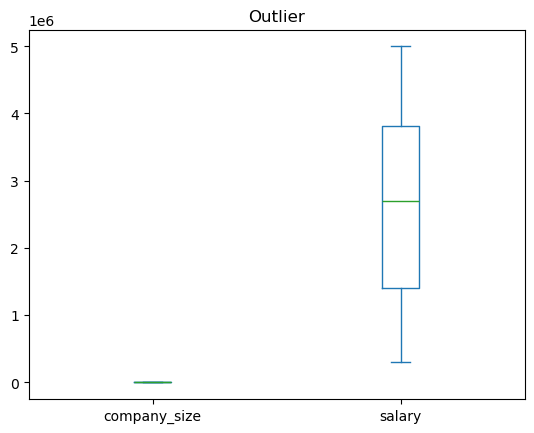

In [44]:
df.plot(kind="box")
plt.title("Outlier")
plt.show()

## 6.Visualization

## Histogram

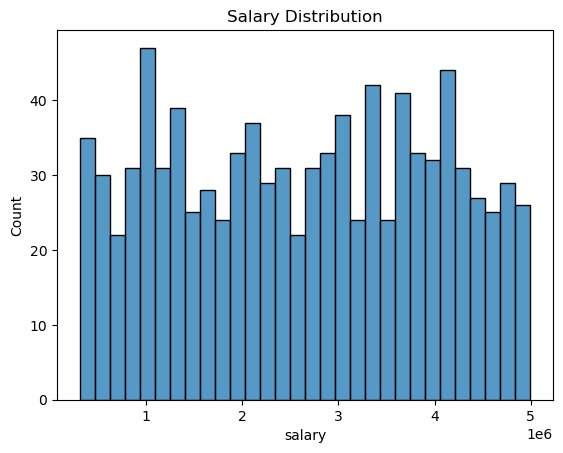

In [45]:
sns.histplot(df['salary'], bins=30)
plt.title('Salary Distribution')
plt.show()

## Que 1.What is the overall distribution of salaries?

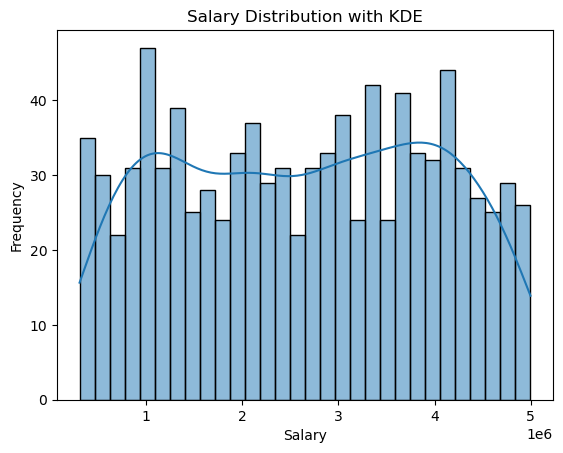

In [46]:
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Salary Distribution with KDE')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

## Insights

1.Most salaries are in a similar range but still vary between jobs.

2.Some very high or low salaries stand out as outliers.

## Box Plot

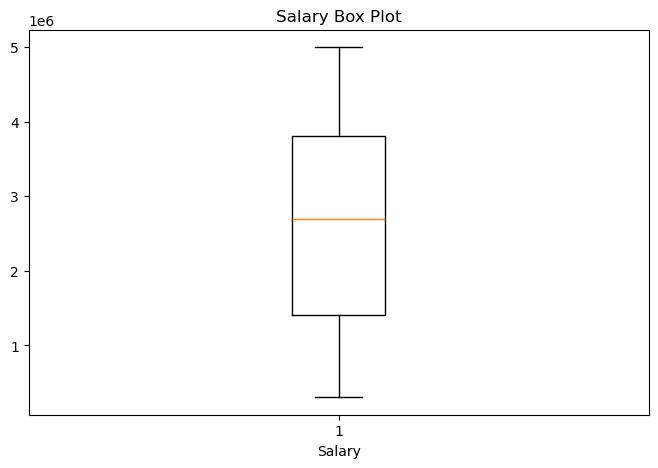

In [50]:
plt.figure(figsize=(8,5))
plt.boxplot(df['salary'])
plt.title("Salary Box Plot")
plt.xlabel("Salary")
plt.show()

## Que 2.Which job roles offer higher salaries?

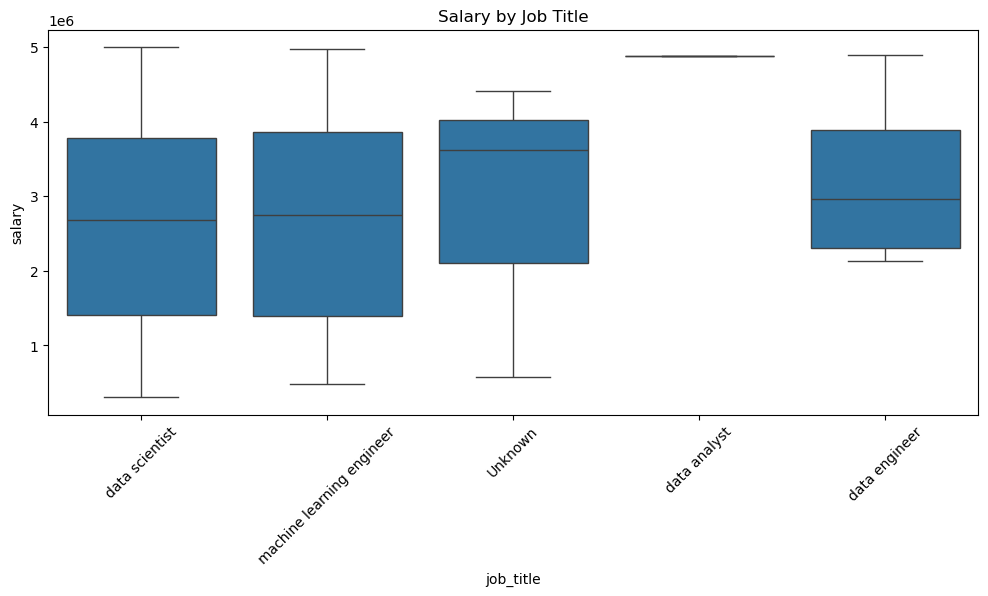

In [51]:
plt.figure(figsize=(12,5))
sns.boxplot(x='job_title', y='salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary by Job Title")
plt.show()

## Insights

1.Some roles (like Data Scientist, ML Engineer) have higher median salaries

2.Helps identify high-paying roles

## Bar Plot

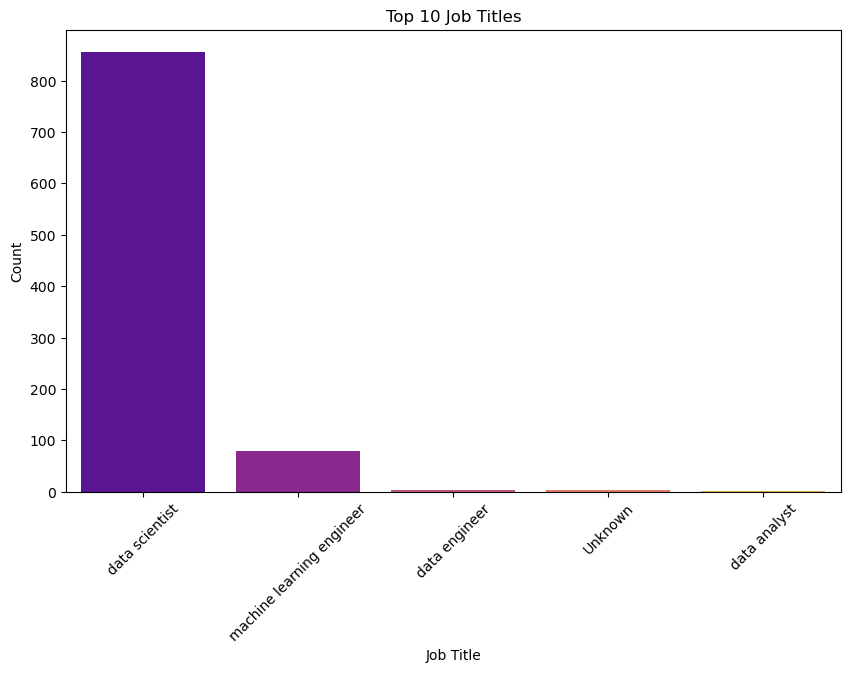

In [53]:
plt.figure(figsize=(10,6))
top_jobs = df['job_title'].value_counts().head(10)
sns.barplot(x=top_jobs.index, y=top_jobs.values, palette='plasma')
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Que 3.How do job titles vary by seniority level?

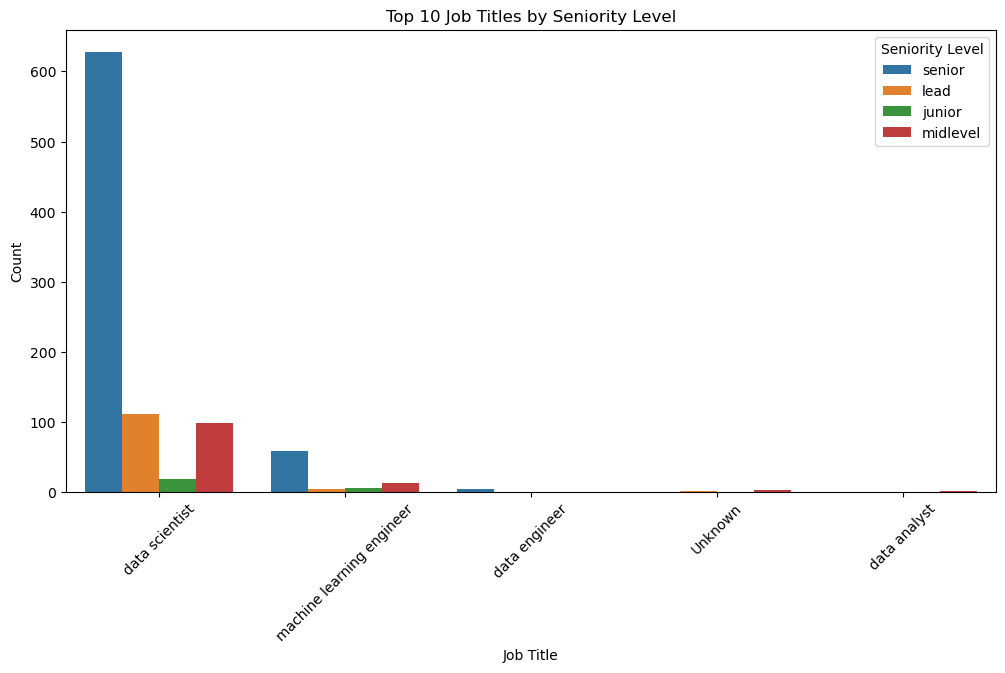

In [54]:
plt.figure(figsize=(12,6))
sns.countplot(data=df[df['job_title'].isin(top_jobs.index)], 
              x='job_title', hue='seniority_level', 
              order=top_jobs.index, palette='tab10')
plt.title("Top 10 Job Titles by Seniority Level")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Seniority Level")
plt.show()

## Insights

1. Top job roles are mostly filled by mid and senior-level candidates, showing a strong preference for experience.

2. Entry-level opportunities are limited, making it harder for freshers to enter high-demand roles.


## Count Plot

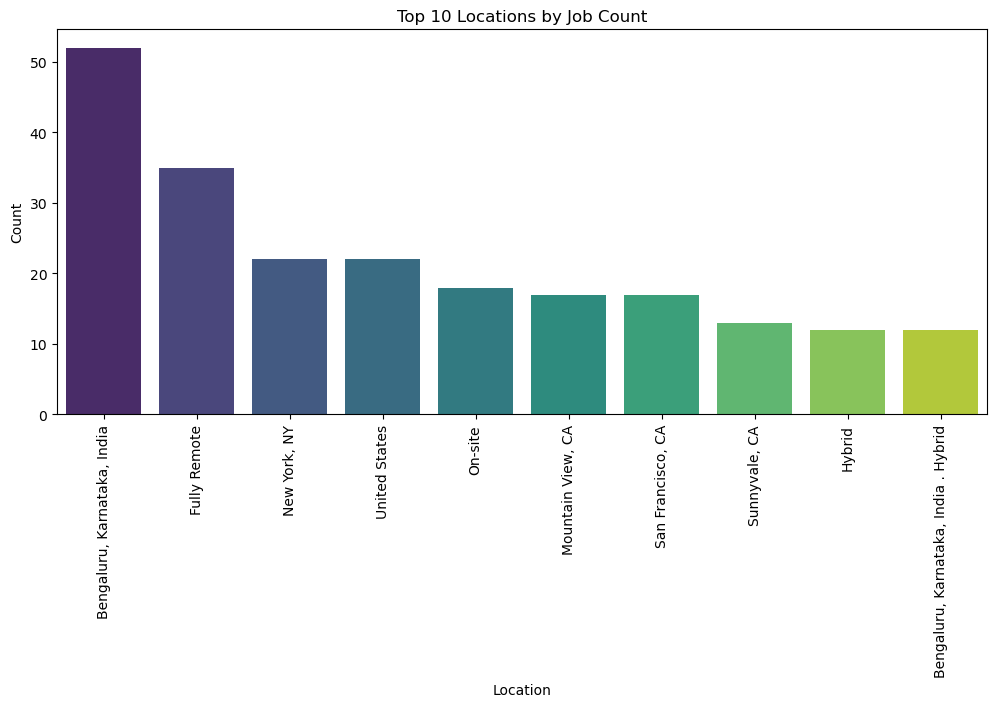

In [57]:
plt.figure(figsize=(12,5))
sns.countplot(x='location', data=df, order=df['location'].value_counts().head(10).index, palette='viridis')
plt.title("Top 10 Locations by Job Count")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Que 4.How do work modes (remote, hybrid, on-site) vary across top locations?

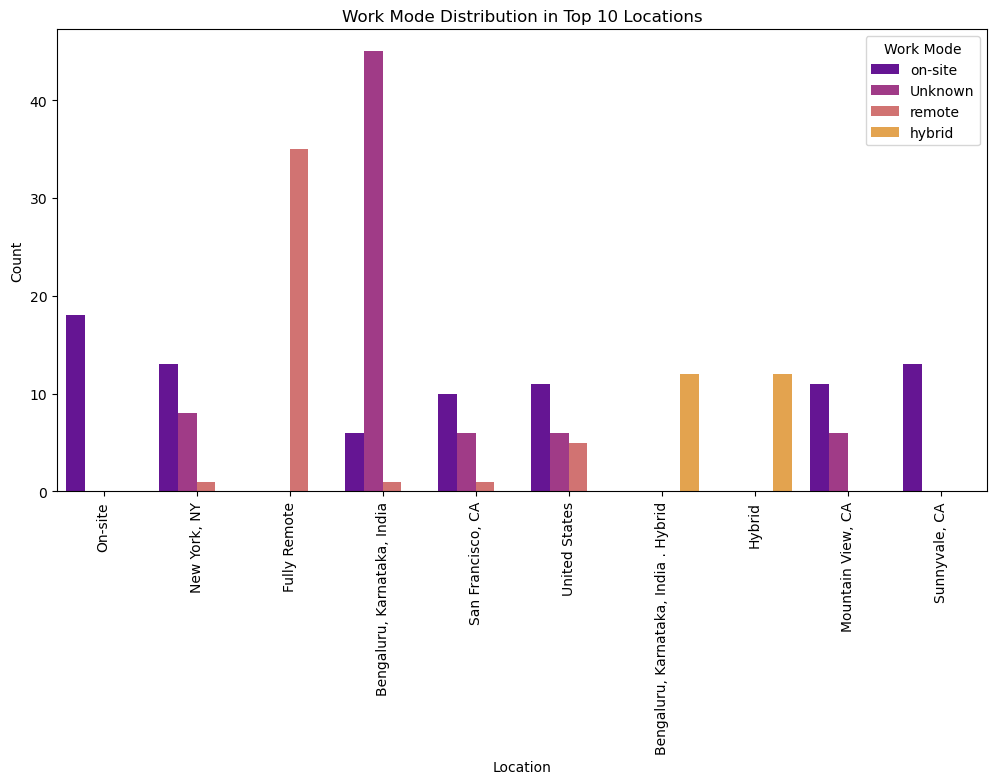

In [58]:
plt.figure(figsize=(12,6))
sns.countplot(data=df[df['location'].isin(df['location'].value_counts().head(10).index)], 
              x='location', hue='status', palette='plasma')
plt.title("Work Mode Distribution in Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Work Mode")
plt.show()


## Insights

1.Most jobs are in a few main locations.

2.Some locations offer more remote or flexible work than others.

## Overall Insights

1. Demand for Python, SQL, ML skills

2. Preference for experienced (senior-level) candidates

3. Presence of missing values / inconsistent data

4. Salary inconsistency / lack of standard format

5. Need for data cleaning before analysis

## Conclusion

1.Most jobs are in a few locations and companies mainly prefer experienced candidates.

2.Skills like Python, SQL, and ML are important, and the data needed proper cleaning due to missing and messy values.

## Solutions

1.Companies should expand hiring to more locations to increase opportunities for freshers.

2.Job seekers should focus on projects, internships, and skills like Python, SQL, and ML.

## Future Improvements

1.Add live job posting data from platforms like LinkedIn or Naukri.

2.Build a dashboard to track hiring trends in real time.

## Real-world Applications:

1.Companies like Amazon or TCS can use it to plan hiring in different cities.

2.Students can use it to focus on skills like Python and SQL that are in demand.